# Nonlinear Classification – Customer Churn Prediction  
**Feature Engineering to Capture Nonlinear Patterns – Machine Learning Lab**

**Objective**  
Demonstrate the **limitations of linear models** in real-world classification tasks and show how simple **feature engineering** (polynomial & interaction terms) can improve performance by making patterns linearly separable in a higher-dimensional space.

**Dataset**  
- **Telco Customer Churn** (IBM sample dataset, widely used in telecom analytics)  
- ~7,043 customers with features like tenure, monthly charges, contract type, internet service, etc.  
- Target: Churn (Yes/No) – imbalanced (~73% retain, ~27% churn)  
- Direct link: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv  
- Realistic telecom problem: churn often depends on nonlinear combinations (e.g., long tenure + low charges → very low churn risk)

**What this notebook demonstrates**  
- Loading & preprocessing mixed-type real data (numeric + categorical)  
- Linear Logistic Regression as baseline (poor on nonlinear interactions)  
- Simple feature engineering: squared terms + key interactions (tenure × charges)  
- Pipeline with scaling, one-hot encoding, and class weighting for imbalance  
- Comparison: accuracy, precision, recall, F1-score + confusion matrices  
- Coefficient interpretation via bar plot (shows important features)

**Key Learning Outcomes**  
- Linear models fail when decision boundaries are nonlinear (common in churn)  
- Polynomial/interaction features provide an intuitive way to add nonlinearity  
- Importance of handling class imbalance (stratification, balanced weights)  
- Why tree-based models or kernels often outperform simple linear + poly tricks  
- Real-world takeaway: churn prediction needs to capture complex customer behavior

Run the cells to see how feature engineering lifts performance on real customer churn data!

In [1]:
%matplotlib inline

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [39]:
# ── 1. Load & clean dataset carefully ───────────────────────────
print("Loading Telco Customer Churn dataset...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

Loading Telco Customer Churn dataset...


In [40]:
# TotalCharges and Churn encoding
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])          # safe drop
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset shape after cleaning: {df.shape}")
print("Churn distribution:\n", df['Churn'].value_counts(normalize=True).round(4))
print("Any missing in target?", df['Churn'].isnull().any())

Dataset shape after cleaning: (7032, 21)
Churn distribution:
 Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64
Any missing in target? False


In [37]:
# ── 2. Feature selection & preprocessing pipeline ───────────────
# Numeric & categorical columns
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

X = df[num_features + cat_features]
y = df['Churn']

# Preprocessing: scale numeric, one-hot categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

In [43]:
if df['Churn'].nunique() < 2:
    raise ValueError("After cleaning, only one class remains in 'Churn' column!")

In [44]:
# ── 2. Features ─────────────────────────────────────────────────
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

X = df[num_features + cat_features]
y = df['Churn']

In [45]:
# ── 3. Preprocessing pipeline ───────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

In [46]:
# ── 4. Train/Test split with stratification & small test size check ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTrain set class distribution:\n", y_train.value_counts(normalize=True).round(4))
print("Test set class distribution:\n", y_test.value_counts(normalize=True).round(4))

if y_train.nunique() < 2:
    raise ValueError("Training set has only one class! Stratification failed or data issue.")


Train set class distribution:
 Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64
Test set class distribution:
 Churn
0    0.7344
1    0.2656
Name: proportion, dtype: float64


In [47]:
# ── 5. Linear Logistic Regression (baseline) ────────────────────
linear_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs'))
])

linear_pipe.fit(X_train, y_train)
y_pred_linear = linear_pipe.predict(X_test)

acc_lin  = accuracy_score(y_test, y_pred_linear)
prec_lin = precision_score(y_test, y_pred_linear)
rec_lin  = recall_score(y_test, y_pred_linear)
f1_lin   = f1_score(y_test, y_pred_linear)
print("\nLinear Logistic Regression Performance:")
print(f"Accuracy : {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall   : {rec_lin:.4f}")
print(f"F1-score : {f1_lin:.4f}")


Linear Logistic Regression Performance:
Accuracy : 0.7332
Precision: 0.4987
Recall   : 0.7966
F1-score : 0.6134


In [48]:
# ── 6. Polynomial/Interaction Features version ──────────────────
df_poly = df.copy()
poly_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in poly_features:
    df_poly[f'{col}_sq'] = df_poly[col] ** 2
df_poly['tenure_x_charges'] = df_poly['tenure'] * df_poly['MonthlyCharges']

extra_poly_cols = [f'{col}_sq' for col in poly_features] + ['tenure_x_charges']

X_poly = df_poly[num_features + cat_features + extra_poly_cols]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.25, random_state=42, stratify=y
)

poly_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', solver='lbfgs'))
])

poly_pipe.fit(X_train_p, y_train_p)
y_pred_poly = poly_pipe.predict(X_test_p)

acc_poly  = accuracy_score(y_test_p, y_pred_poly)
prec_poly = precision_score(y_test_p, y_pred_poly)
rec_poly  = recall_score(y_test_p, y_pred_poly)
f1_poly   = f1_score(y_test_p, y_pred_poly)

print("\nWith Polynomial/Interaction Features Performance:")
print(f"Accuracy : {acc_poly:.4f}")
print(f"Precision: {prec_poly:.4f}")
print(f"Recall   : {rec_poly:.4f}")
print(f"F1-score : {f1_poly:.4f}")


With Polynomial/Interaction Features Performance:
Accuracy : 0.7332
Precision: 0.4987
Recall   : 0.7966
F1-score : 0.6134


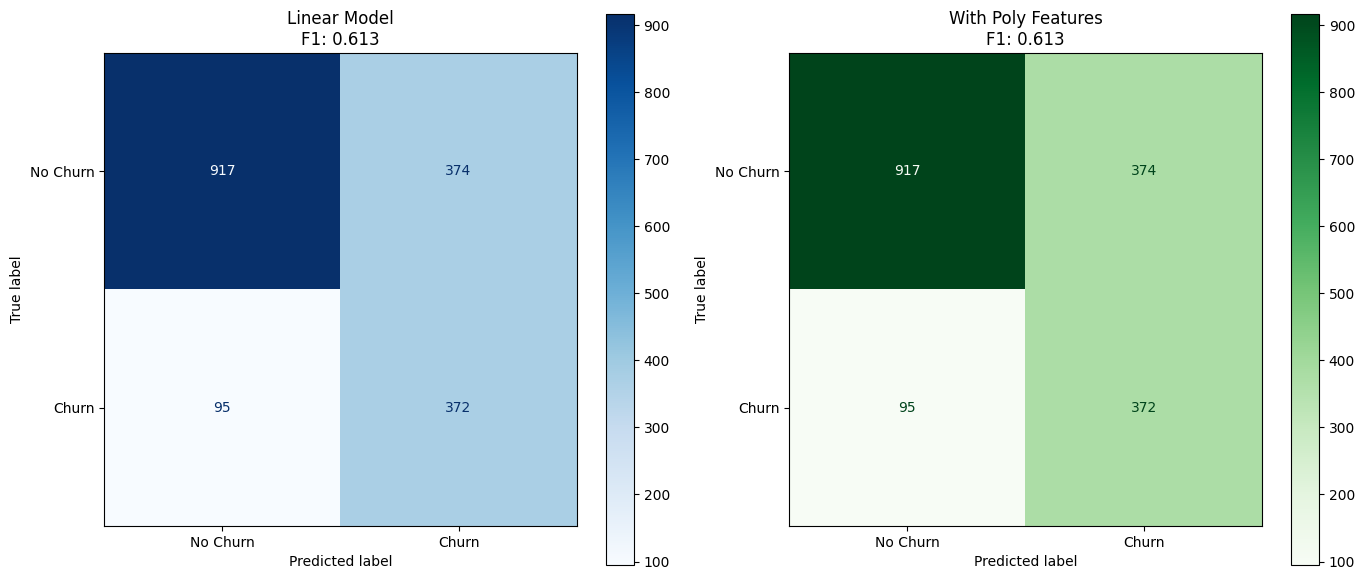

In [49]:
#── 7. Confusion Matrices Comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_lin = confusion_matrix(y_test, y_pred_linear)
disp_lin = ConfusionMatrixDisplay(cm_lin, display_labels=["No Churn", "Churn"])
disp_lin.plot(ax=axes[0], cmap="Blues", values_format='d')
axes[0].set_title(f"Linear Model\nF1: {f1_lin:.3f}")

cm_poly = confusion_matrix(y_test_p, y_pred_poly)
disp_poly = ConfusionMatrixDisplay(cm_poly, display_labels=["No Churn", "Churn"])
disp_poly.plot(ax=axes[1], cmap="Greens", values_format='d')
axes[1].set_title(f"With Poly Features\nF1: {f1_poly:.3f}")

plt.tight_layout()
plt.show()

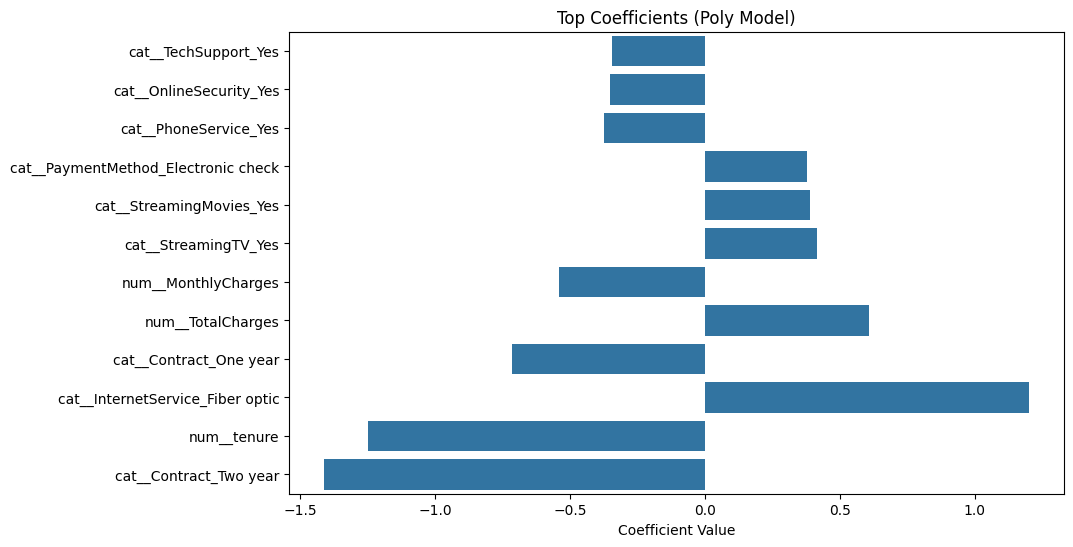

In [51]:
# top coefficients from poly model
coefs = poly_pipe.named_steps['clf'].coef_[0]
feat_names = poly_pipe.named_steps['prep'].get_feature_names_out()
top_idx = np.argsort(np.abs(coefs))[-12:]
plt.figure(figsize=(10, 6))
sns.barplot(x=coefs[top_idx], y=feat_names[top_idx])
plt.title("Top Coefficients (Poly Model)")
plt.xlabel("Coefficient Value")
plt.show()